<a href="https://colab.research.google.com/github/jaylen-shen/820Jaylen/blob/main/Lora%E5%BE%AE%E8%B0%83wiki%E7%99%BE%E7%A7%91.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers peft

In [133]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# 加载预训练的 GPT-2 模型和分词器
tokenizer = AutoTokenizer.from_pretrained('gpt2')
base_model = AutoModelForCausalLM.from_pretrained('gpt2')

# 关键修复：添加填充标记
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token  # 使用结束标记作为填充标记


base_model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [121]:
# 2. 准备英文数据集 - 使用 WikiText-2 数据集
def prepare_dataset():
    # 加载数据集
    dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

    # 过滤空行
    dataset = dataset.filter(lambda example: len(example["text"]) > 0)

    # 预处理函数
    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            max_length=256,  # 截断到256个token
            padding=False,    # 不在此处填充，在DataCollator中处理
            return_tensors=None
        )
    print(dataset["validation"][0])

    # 应用分词器
    tokenized_dataset = dataset.map(
        tokenize_function,
        batched=True,
        remove_columns=["text"]  # 移除原始文本列
    )

    return tokenized_dataset

# 3. 准备数据集
dataset = prepare_dataset()
train_dataset = dataset["train"]  # 训练集
# 如果需要验证集，可以使用 dataset["validation"]

{'text': ' = Homarus gammarus = \n'}


Map:   0%|          | 0/2891 [00:00<?, ? examples/s]

Map:   0%|          | 0/23767 [00:00<?, ? examples/s]

Map:   0%|          | 0/2461 [00:00<?, ? examples/s]

In [88]:
train_dataset

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 23767
})

In [89]:
from peft import get_peft_model, LoraConfig, TaskType

# 配置 LoRA
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,  # 任务类型：因果语言模型
    inference_mode=False,          # 推理模式关闭，以进行训练
    r=8,                           # 低秩值 r
    lora_alpha=32,                 # LoRA 的缩放因子
    lora_dropout=0.1,              # Dropout 概率
)

# 将 LoRA 应用到模型中
model = get_peft_model(base_model, lora_config)

/usr/local/lib/python3.11/dist-packages/peft/tuners/lora/layer.py:1803: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


In [102]:
print(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): GPT2LMHeadModel(
      (transformer): GPT2Model(
        (wte): Embedding(50257, 768)
        (wpe): Embedding(1024, 768)
        (drop): Dropout(p=0.1, inplace=False)
        (h): ModuleList(
          (0-11): 12 x GPT2Block(
            (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (attn): GPT2Attention(
              (c_attn): lora.Linear(
                (base_layer): Conv1D(nf=2304, nx=768)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=768, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2304, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
           

In [91]:
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling
# 6. 创建数据整理器 - 用于动态填充
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False  # 不是掩码语言建模
)

# 7. 定义训练参数
training_args = TrainingArguments(
    output_dir='./results',         # 模型保存目录
    num_train_epochs=3,             # 训练轮数
    per_device_train_batch_size=8,  # 批次大小（根据GPU显存调整）
    learning_rate=2e-5,             # 学习率
    logging_steps=100,              # 日志记录步数
    save_steps=500,                 # 保存模型步数
    save_total_limit=1,             # 最多保存1个模型
    report_to="none",               # 禁用报告
    fp16=True,                      # 使用混合精度训练
    gradient_accumulation_steps=2,  # 梯度累积
)

# 8. 创建 Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=data_collator,    # 添加数据整理器
)

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [92]:
# 9. 开始训练
print("开始训练...")
trainer.train()
print("训练完成!")

# 10. 保存模型
trainer.save_model("./trained_lora_model")

开始训练...


Step,Training Loss
100,4.208700
200,4.076800
300,4.008500
400,3.938000
500,3.895100
600,3.855700
700,3.842000
800,3.794000
900,3.775100
1000,3.760900


训练完成!


In [136]:
from transformers import pipeline
generator = pipeline(
    "text-generation",
    model="./trained_lora_model",
    tokenizer="gpt2"
)
# 测试不同类型的输入
prompts = [
    # 文本续写
    "the capital of USA is",

    # 主题段落生成
    "Renewable energy sources have several advantages:",

    # 列表续写
    "Major programming languages:\n1. Python\n2. JavaScript\n3.",

    # 定义解释
    "Artificial intelligence refers to"
]

for prompt in prompts:
    print(f"\n输入: {prompt}")
    output = generator(
        prompt,
        max_length=150,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.2,
        num_return_sequences=1
    )
    print(f"输出: {output[0]['generated_text']}")
    print("-" * 80)

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



输入: the capital of USA is


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


输出: the capital of USA is not a country ; it was founded in 1859, and its founding period has been marked by two distinct phases. The first phase began with the annexation of Washington DC to Britain from 1789 into 1693 and continued through 1898 as part, or partial withdrawal (with no final decision on their future ) until 1907 when they were formally declared sovereign states under Article I. In 1911 an agreement between Congress and Great Britain resulted whereby all British possessions within US territory would be recognised at any time after 1918 while American-born citizens could only enter America for temporary residence permits during periods defined by congressional legislation rather than being automatically granted citizenship based solely upon immigration status if such permission had previously expired before that date. After WWI the United States became independent again following World War II which saw Russia become fully involved in East Asia via North Korea's invasion 

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


输出: Renewable energy sources have several advantages:
 1. They are less costly than fossil fuels 2. In the United States, natural gas is cheaper and more abundant ( ). This makes them a major source of renewable electricity in many parts such as California ; however, wind power costs significantly higher due to its low cost compared with other renewables 3 • As mentioned above electric vehicles make up only around 15% or so % <10 percent / year on average 4. There has been considerable debate about whether climate change will lead us to abandon coal for nuclear - especially since it was recently suggested that carbon emissions would be reduced if we stopped using petroleum @@-@ 40 CO2's per kilowatt hour fuel instead 5  In fact, one recent paper by two scientists at Cornell University published estimates estimating "a substantial reduction in global greenhouse gas emission" after 2030 6   However this approach does not account solely solar PV systems 7 9 ) Therefore there may still rem

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


输出: Major programming languages:
1. Python
2. JavaScript
3. Ruby
4.NET Core 2 ( @-@ )
5 – 6 : https://githubusercontent/mjkoenikoski / django_webengine " API # of Views is used for most views in Django 1, but this one has a lot more than that, as there are many other common APIs available to implement the same thing — including natively supported frameworks like Meteor and AngularJS ; some examples include Firebase or Laravel with Ember CLI support on top; jQuery plugins such AsyncJavascript's Ajax plugin which can be included into any framework without needing authentication by default due only via AJAX request handling so you don't need an external server connection at all when running it directly from your web browser using custom scripts written entirely within its own app directory rather then calling yourself out manually through HTTP requests instead … The idea behind these methods was born over years ago because they were easy enough to follow & maintain throughout development 

In [135]:
from transformers import pipeline
generator = pipeline(
    "text-generation",
    model=base_model,
    tokenizer="gpt2"
)
# 测试不同类型的输入
prompts = [
    # 文本续写
    "the capital of united states of America is",

    # 主题段落生成
    "Renewable energy sources have several advantages:",

    # 列表续写
    "Major programming languages:\n1. Python\n2. JavaScript\n3.",

    # 定义解释
    "Artificial intelligence refers to"
]

for prompt in prompts:
    print(f"\n输入: {prompt}")
    output = generator(
        prompt,
        max_length=150,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.2,
        num_return_sequences=1
    )
    print(f"输出: {output[0]['generated_text']}")
    print("-" * 80)

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



输入: the capital of united states of America is


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


输出: the capital of united states of America is the United States. We are, therefore, not only a sovereign nation and protector of our freedom from foreign interference but also an indispensable part in bringing about its independence."
"In this respect," he continued "we owe it to you that we continue as one people under your rule who have always been guided by justice; for if any government should fall into disorder or usurp power without due process of law then those governments which possess absolute sovereignty over us will be condemned with ignominy among nations everywhere except at present where they can no longer afford even their own protection.... If these circumstances arise now upon other occasions when peace must prevail on every side against tyranny... [then] I would respectfully request President Truman to order me, after giving his approbation theretofore requested through Secretary Marshall..." (The Speech: The Declaration of Independence)

-President Franklin D Roosev

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


输出: Renewable energy sources have several advantages:
- They are less expensive to build than fossil fuels and they can be easily converted into power plants. If you buy a gas station in Chicago, for example; the building materials of your car will not come from oil or natural gases as often it does now (but those same resources would still exist). The cost is lower because there's no need that every electric vehicle needs an electrical outlet. It also means fewer people who don't drive cars -- especially if their jobs require them! In addition, all solar panels could replace electricity generated by batteries over time due either direct sunlight on top [i]or indirect sunburns during which light comes back off one side instead causing more heat loss per watt squared compared with coal/gasoline powered vehicles where each person has equal access to both sides--it just requires far greater amounts at least when combined with wind turbines."

 [1]. http://www3.bpornetworkonlinehostedaily.

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


输出: Major programming languages:
1. Python
2. JavaScript
3. PHP 5.0 (Chrome, Firefox and Safari)
4.NET 4G/5E mobile OS : Android, iOS


--------------------------------------------------------------------------------

输入: Artificial intelligence refers to
输出: Artificial intelligence refers to techniques that can be applied in a variety of ways. It is often referred as "superintelligence," or the ability for artificial intelligent agents to predict, react and manipulate events based on human thinking patterns (the latter being called AI).
The term has also been used by some scientists who have questioned whether it accurately describes reality—a question they've had many times before: how does one explain something if its properties are such? But what about our own understanding of nature itself? What do we know without looking at ourselves directly from an evolutionary perspective? How much more complicated would this kind 2-D experience look like when humans were living among us than 

In [137]:
# ====== 步骤 1: 加载基础模型和分词器 ======
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel, PeftConfig

# 加载基础模型
model_name = "gpt2"  # 与训练时相同的基础模型
base_model = AutoModelForCausalLM.from_pretrained(model_name)

# 加载分词器
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token  # 确保设置了填充token

# ====== 步骤 2: 加载训练好的 LoRA 适配器 ======
peft_model_path = "./trained_lora_model"  # 训练时保存的路径

# 加载 LoRA 配置
config = PeftConfig.from_pretrained(peft_model_path)

# 将 LoRA 适配器应用到基础模型
trained_model = PeftModel.from_pretrained(base_model, peft_model_path)

# ====== 步骤 3: 使用模型进行推理 ======
def generate_text(prompt, max_new_tokens=100, temperature=0.7):
    """使用训练后的模型生成文本"""
    inputs = tokenizer(prompt, return_tensors="pt").to(trained_model.device)

    outputs = trained_model.generate(
        inputs.input_ids,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_p=0.9,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# 测试生成
prompts = [
    "The Industrial Revolution began in",
    "Quantum mechanics differs from classical physics in that",
    "The key features of the Renaissance period were"
]

print("训练后模型生成示例:")
for prompt in prompts:
    response = generate_text(prompt)
    print(f"\n提示: {prompt}")
    print(f"生成结果: {response[len(prompt):].strip()}")
    print("-" * 80)

# ====== 步骤 4: 合并模型 (可选) ======
# 如果您想创建一个独立的模型文件（包含LoRA权重）
merged_model = trained_model.merge_and_unload()
merged_model.save_pretrained("./merged_model")
tokenizer.save_pretrained("./merged_model")

print("\n合并后的模型已保存到 './merged_model'")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


训练后模型生成示例:


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



提示: The Industrial Revolution began in
生成结果: the United States , and was followed by a period of rapid technological change . The first major changes were made to agriculture : mechanization ( 1885 ) and automation ( 1886 ). 

In addition, advances in technology such as computers led many farmers to abandon their traditional farming practices for better agricultural productivity . In contrast with this trend , there are still some areas where modern technologies have been used successfully ; however these include: • irrigation systems that allow water from rivers or streams into lakes @-@ aqu
--------------------------------------------------------------------------------


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



提示: Quantum mechanics differs from classical physics in that
生成结果: it is based on the principle of conservation . The fundamental principles are:

1. A constant value (or a fixed number) can be expressed as an absolute quantity , i : ∂ x = 1 + 2 × 10 − 3 / 4 ≈ 0 and vice versa for any given set of values ; this means that if we have two sets of constants, one with zero or positive momentum at each end and another without such force then they will always equal to infinity because there must be no
--------------------------------------------------------------------------------

提示: The key features of the Renaissance period were
生成结果: :
 ' The first major change was in how people viewed art . In 1789 , a new type of painting called " Picasso " became popular and began to be used as an artistic medium for drawing. This style had been developed by artists such Asa Butterfield ( 1803 – 1900 ) and Alfredo de la Torre ( 1800 – 1901 ), who painted portraits with their own brush strokes on can

加载基础模型...
加载合并模型...
加载验证数据集...

计算基础模型困惑度...


计算困惑度: 100%|██████████| 25/25 [01:50<00:00,  4.42s/it]



计算合并模型困惑度...


计算困惑度: 100%|██████████| 25/25 [01:50<00:00,  4.42s/it]
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



基础模型 - 困惑度: 1160.24, 平均损失: 7.0564
合并模型 - 困惑度: 319.98, 平均损失: 5.7683
改进比例: 72.4%

文本生成对比测试:

提示: The Industrial Revolution began in


...

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


基础模型准确率: 0.0%
合并模型准确率: 60.0%
提升: 60.0%

详细回答对比:

问题 1: Where was the Industrial Revolution born?
基础模型: it started with a revolution in agriculture. the first industrial revolutions were based on small-scale farming, ✗
合并模型: the first industrial revolution began in england around 1780 . it started with a series of strikes and riots ✓

问题 2: Who developed the theory of relativity?
基础模型: it's not a matter for me to say. i'm just saying that it is possible, and ✗
合并模型: the first principle is that all objects in space are moving at a constant speed . this means they have ✗

问题 3: What is the capital of France?
基础模型: it's a french word for "the land."
the capital of france (or, more accurately ✗
合并模型: paris . the french name for it was " la marseille " , which means ' city ' in ✓

问题 4: Which element has the atomic number 1?
基础模型: yes.
the answer is that it's a function of type t . the first argument to this ✗
合并模型: the atom is a member of an ordered group consisting of two elements . each 

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


基础模型主题分布:
Science: 0 (0.0%)
History: 10 (20.0%)
Technology: 30 (60.0%)
Art: 0 (0.0%)
Other: 10 (20.0%)

合并模型主题分布:
Science: 10 (20.0%)
History: 0 (0.0%)
Technology: 30 (60.0%)
Art: 0 (0.0%)
Other: 10 (20.0%)


/tmp/ipython-input-507310036.py:242: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-507310036.py:242: UserWarning: Glyph 39064 (\N{CJK UNIFIED IDEOGRAPH-9898}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-507310036.py:242: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-507310036.py:242: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-507310036.py:242: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-507310036.py:242: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-507310036.py:242: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missi

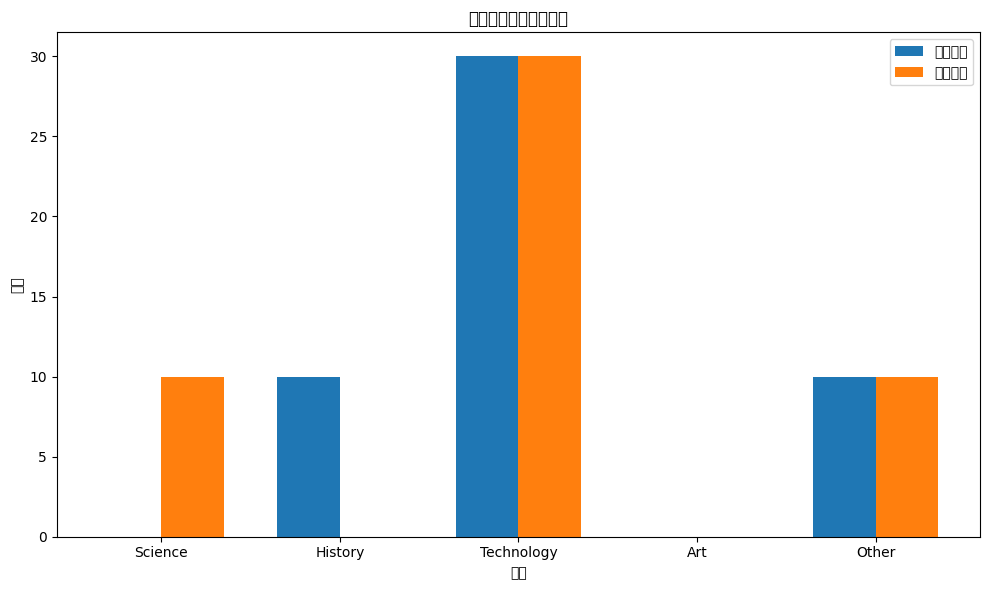

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



词汇多样性分析:


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

基础模型 - 总token数: 2265, 唯一token数: 297, 多样性(TTR): 0.1311
合并模型 - 总token数: 2535, 唯一token数: 322, 多样性(TTR): 0.1270


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



对比报告已保存到 model_comparison_report.txt


In [139]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel, PeftConfig
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# ===== 1. 加载模型和分词器 =====
model_name = "gpt2"
peft_model_path = "./merged_model"  # 训练好的LoRA模型路径

# 加载基础模型
print("加载基础模型...")
base_model = AutoModelForCausalLM.from_pretrained(model_name)
base_tokenizer = AutoTokenizer.from_pretrained(model_name)
base_tokenizer.pad_token = base_tokenizer.eos_token

# 加载合并模型
print("加载合并模型...")
#config = PeftConfig.from_pretrained(peft_model_path)
merged_model = AutoModelForCausalLM.from_pretrained(peft_model_path)  # 如果已合并
# 或者从LoRA合并:
# base_model = AutoModelForCausalLM.from_pretrained(config.base_model_name_or_path)
# merged_model = PeftModel.from_pretrained(base_model, peft_model_path).merge_and_unload()

merged_tokenizer = AutoTokenizer.from_pretrained(peft_model_path)

# ===== 2. 准备验证数据集 =====
print("加载验证数据集...")
val_dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="validation")
val_dataset = val_dataset.filter(lambda x: len(x["text"]) > 0)
small_val_dataset = val_dataset.select(range(200))  # 使用200个样本

# ===== 3. 计算困惑度对比 =====
def calculate_perplexity(model, tokenizer, dataset, max_length=256, batch_size=8):
    """计算困惑度"""
    model.eval()
    device = model.device

    def collate_fn(batch):
        texts = [item["text"] for item in batch]
        inputs = tokenizer(
            texts,
            max_length=max_length,
            truncation=True,
            padding=True,
            return_tensors="pt"
        )
        return inputs

    dataloader = DataLoader(dataset, batch_size=batch_size, collate_fn=collate_fn)

    total_loss = 0
    total_tokens = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="计算困惑度"):
            inputs = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**inputs, labels=inputs["input_ids"])
            loss = outputs.loss
            mask = inputs["attention_mask"]
            num_tokens = mask.sum().item()
            total_loss += loss.item() * num_tokens
            total_tokens += num_tokens

    avg_loss = total_loss / total_tokens
    perplexity = torch.exp(torch.tensor(avg_loss)).item()
    return perplexity, avg_loss

print("\n计算基础模型困惑度...")
base_ppl, base_loss = calculate_perplexity(base_model, base_tokenizer, small_val_dataset)

print("\n计算合并模型困惑度...")
merged_ppl, merged_loss = calculate_perplexity(merged_model, merged_tokenizer, small_val_dataset)

print(f"\n{'='*50}")
print(f"基础模型 - 困惑度: {base_ppl:.2f}, 平均损失: {base_loss:.4f}")
print(f"合并模型 - 困惑度: {merged_ppl:.2f}, 平均损失: {merged_loss:.4f}")
print(f"改进比例: {(base_ppl - merged_ppl) / base_ppl * 100:.1f}%")
print('='*50)

# ===== 4. 文本生成对比 =====
def generate_text(model, tokenizer, prompt, max_new_tokens=100):
    """生成文本"""
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        inputs.input_ids,
        max_new_tokens=max_new_tokens,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.pad_token_id
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# 选择WikiText相关提示
wiki_prompts = [
    "The Industrial Revolution began in",
    "Quantum mechanics differs from classical physics in that",
    "The key features of Renaissance art include",
    "The Treaty of Versailles was significant because",
    "Photosynthesis is the process by which"
]

print("\n文本生成对比测试:")
for prompt in wiki_prompts:
    print(f"\n{'='*80}")
    print(f"提示: {prompt}")

    base_output = generate_text(base_model, base_tokenizer, prompt)
    merged_output = generate_text(merged_model, merged_tokenizer, prompt)

    print(f"\n基础模型生成:\n{base_output[len(prompt):].strip()}")
    print(f"\n合并模型生成:\n{merged_output[len(prompt):].strip()}")
    print('='*80)

# ===== 5. 知识准确性测试 =====
def test_knowledge_accuracy(model, tokenizer, questions, answers):
    """测试知识准确性"""
    correct = 0
    responses = []

    for question, expected in zip(questions, answers):
        prompt = f"{question} Answer:"
        response = generate_text(model, tokenizer, prompt, max_new_tokens=20)
        response = response[len(prompt):].strip().lower()

        # 检查是否包含正确答案
        if any(keyword in response for keyword in expected):
            correct += 1
            responses.append((question, response, "✓"))
        else:
            responses.append((question, response, "✗"))

    accuracy = correct / len(questions) * 100
    return accuracy, responses

# 定义问题和预期答案
knowledge_questions = [
    "Where was the Industrial Revolution born?",
    "Who developed the theory of relativity?",
    "What is the capital of France?",
    "Which element has the atomic number 1?",
    "What is the largest planet in our solar system?"
]

expected_answers = [
    ["britain", "england", "uk"],
    ["einstein"],
    ["paris"],
    ["hydrogen"],
    ["jupiter"]
]

print("\n知识准确性测试:")
base_accuracy, base_responses = test_knowledge_accuracy(base_model, base_tokenizer, knowledge_questions, expected_answers)
merged_accuracy, merged_responses = test_knowledge_accuracy(merged_model, merged_tokenizer, knowledge_questions, expected_answers)

print(f"\n基础模型准确率: {base_accuracy:.1f}%")
print(f"合并模型准确率: {merged_accuracy:.1f}%")
print(f"提升: {merged_accuracy - base_accuracy:.1f}%")

print("\n详细回答对比:")
for i, (q, base_r, base_mark) in enumerate(base_responses):
    _, merged_r, merged_mark = merged_responses[i]
    print(f"\n问题 {i+1}: {q}")
    print(f"基础模型: {base_r} {base_mark}")
    print(f"合并模型: {merged_r} {merged_mark}")

# ===== 6. 主题分布分析 =====
def analyze_topic_distribution(model, tokenizer, prompts):
    """分析生成文本的主题分布"""
    topics = {
        "science": 0,
        "history": 0,
        "technology": 0,
        "art": 0,
        "other": 0
    }
    topic_keywords = {
        "science": ["science", "scientist", "physics", "chemistry", "biology"],
        "history": ["history", "historical", "war", "revolution", "century"],
        "technology": ["technology", "computer", "internet", "digital", "ai"],
        "art": ["art", "artist", "painting", "music", "literature"]
    }

    for prompt in prompts:
        response = generate_text(model, tokenizer, prompt, max_new_tokens=50)
        response = response.lower()

        # 统计关键词出现
        for topic, keywords in topic_keywords.items():
            if any(keyword in response for keyword in keywords):
                topics[topic] += 1
                break
        else:
            topics["other"] += 1

    return topics

# 使用中性提示
neutral_prompts = [
    "The most important development in",
    "One fascinating aspect of",
    "A key breakthrough in",
    "The evolution of",
    "The impact of"
] * 10  # 生成50个样本

print("\n主题分布分析:")
base_topics = analyze_topic_distribution(base_model, base_tokenizer, neutral_prompts)
merged_topics = analyze_topic_distribution(merged_model, merged_tokenizer, neutral_prompts)

print("\n基础模型主题分布:")
for topic, count in base_topics.items():
    print(f"{topic.capitalize()}: {count} ({count/50*100:.1f}%)")

print("\n合并模型主题分布:")
for topic, count in merged_topics.items():
    print(f"{topic.capitalize()}: {count} ({count/50*100:.1f}%)")

# 可视化对比
fig, ax = plt.subplots(figsize=(10, 6))
topics = list(base_topics.keys())
base_counts = list(base_topics.values())
merged_counts = list(merged_topics.values())

bar_width = 0.35
index = np.arange(len(topics))

ax.bar(index, base_counts, bar_width, label='基础模型')
ax.bar(index + bar_width, merged_counts, bar_width, label='合并模型')

ax.set_xlabel('主题')
ax.set_ylabel('计数')
ax.set_title('模型生成主题分布对比')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels([t.capitalize() for t in topics])
ax.legend()

plt.tight_layout()
plt.savefig('topic_distribution_comparison.png')
plt.show()

# ===== 7. 词汇多样性分析 =====
def calculate_lexical_diversity(model, tokenizer, prompts):
    """计算词汇多样性"""
    all_tokens = []

    for prompt in prompts:
        response = generate_text(model, tokenizer, prompt, max_new_tokens=100)
        tokens = tokenizer.tokenize(response)
        all_tokens.extend(tokens)

    # 计算词汇多样性 (Type-Token Ratio)
    unique_tokens = set(all_tokens)
    ttr = len(unique_tokens) / len(all_tokens) if all_tokens else 0

    return ttr, len(unique_tokens), len(all_tokens)

print("\n词汇多样性分析:")
base_ttr, base_unique, base_total = calculate_lexical_diversity(base_model, base_tokenizer, wiki_prompts * 5)
merged_ttr, merged_unique, merged_total = calculate_lexical_diversity(merged_model, merged_tokenizer, wiki_prompts * 5)

print(f"基础模型 - 总token数: {base_total}, 唯一token数: {base_unique}, 多样性(TTR): {base_ttr:.4f}")
print(f"合并模型 - 总token数: {merged_total}, 唯一token数: {merged_unique}, 多样性(TTR): {merged_ttr:.4f}")

# ===== 8. 保存完整对比报告 =====
with open("model_comparison_report.txt", "w") as f:
    f.write("===== 模型对比报告 =====\n")
    f.write(f"基础模型: {model_name}\n")
    f.write(f"合并模型: {peft_model_path}\n")
    f.write(f"数据集: WikiText-2\n\n")

    f.write("===== 困惑度对比 =====\n")
    f.write(f"基础模型困惑度: {base_ppl:.2f}\n")
    f.write(f"合并模型困惑度: {merged_ppl:.2f}\n")
    f.write(f"改进比例: {(base_ppl - merged_ppl) / base_ppl * 100:.1f}%\n\n")

    f.write("===== 知识准确性对比 =====\n")
    f.write(f"基础模型准确率: {base_accuracy:.1f}%\n")
    f.write(f"合并模型准确率: {merged_accuracy:.1f}%\n")
    f.write(f"提升: {merged_accuracy - base_accuracy:.1f}%\n\n")

    f.write("===== 主题分布对比 =====\n")
    f.write("基础模型:\n")
    for topic, count in base_topics.items():
        f.write(f"  {topic.capitalize()}: {count} ({count/50*100:.1f}%)\n")
    f.write("\n合并模型:\n")
    for topic, count in merged_topics.items():
        f.write(f"  {topic.capitalize()}: {count} ({count/50*100:.1f}%)\n")

    f.write("\n===== 词汇多样性对比 =====\n")
    f.write(f"基础模型 TTR: {base_ttr:.4f}\n")
    f.write(f"合并模型 TTR: {merged_ttr:.4f}\n")

    f.write("\n===== 生成示例对比 =====\n")
    for i, prompt in enumerate(wiki_prompts[:3]):
        f.write(f"\n提示 {i+1}: {prompt}\n")
        base_output = generate_text(base_model, base_tokenizer, prompt)
        merged_output = generate_text(merged_model, merged_tokenizer, prompt)
        f.write(f"基础模型:\n{base_output}\n\n")
        f.write(f"合并模型:\n{merged_output}\n")
        f.write("-" * 80 + "\n")

print("\n对比报告已保存到 model_comparison_report.txt")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


china's capital is a city of more than 1.5 million people, and the capital city of the country's largest
